# Understanding Distributions Through Customer Data

This notebook explores **probability distributions** using real customer-related data.

The goal is not mathematical derivation, but to develop strong intuition around:
- when to use different distributions
- how to interpret their shape
- how they apply to real business problems

Distributions covered:
- Normal distribution
- Binomial distribution
- Poisson distribution

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../project-2-customer-churn/data/telco-customer-churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Normal Distribution Intuition: Monthly Charges

The normal distribution is commonly used to model continuous variables
that arise from many small contributing factors.

In this section, we examine whether **Monthly Charges** approximately follow
a normal distribution and what the mean and standard deviation tell us
about customer behavior.

### Initial Assumption

Monthly Charges are continuous values influenced by multiple factors
such as service type, add-ons, and contract structure.
This makes them a reasonable candidate for exploring normal-distribution
intuition before validating the assumption through visualization.

In [9]:
monthly_charges = df["MonthlyCharges"]
monthly_charges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

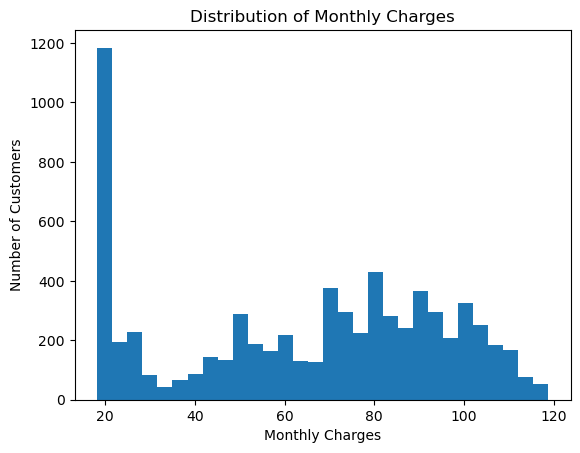

In [13]:
plt.figure()
plt.hist(monthly_charges, bins=30)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

### Re-evaluating the Normality Assumption

Although Monthly Charges are continuous, the histogram reveals a clear
multi-modal structure caused by discrete pricing tiers.
This violates the assumptions of a normal distribution.

This highlights an important lesson:
summary statistics alone are insufficient to infer distribution shape,
and visualization is essential for validating assumptions.

In [10]:
mean_mc = monthly_charges.mean()
std_mc = monthly_charges.std()

within_1sd = (
    (monthly_charges >= mean_mc - std_mc) &
    (monthly_charges <= mean_mc + std_mc)
).mean()

within_2sd = (
    (monthly_charges >= mean_mc - 2*std_mc) &
    (monthly_charges <= mean_mc + 2*std_mc)
).mean()

within_3sd = (
    (monthly_charges >= mean_mc - 3*std_mc) &
    (monthly_charges <= mean_mc + 3*std_mc)
).mean()

within_1sd, within_2sd, within_3sd

(np.float64(0.5683657532301576), np.float64(1.0), np.float64(1.0))

### Interpretation (68–95–99.7 Rule in Context)

The observed proportions deviate from the ideal normal distribution,
with fewer observations within one standard deviation of the mean.

This deviation is expected due to business-imposed pricing constraints,
and reinforces that the normal distribution should be treated as an
approximation rather than a strict model in this context.

## Binomial Distribution: Customer Churn

The binomial distribution models the number of successes in a fixed number
of independent trials, where each trial has a binary outcome.

In this context:
- Each customer represents one trial
- Churn (Yes/No) represents success/failure

In [11]:
# Churn counts
churn_counts = df["Churn"].value_counts()
churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
p_churn = (df["Churn"] == "Yes").mean()
p_churn

np.float64(0.2653698707936959)

### Interpretation

Out of **7,043 customers**, **1,869 churned** and **5,174 did not**.

This corresponds to a churn probability of approximately **26.5%**.
Each customer represents a **single trial** with two possible outcomes:
- Churn = Yes
- Churn = No

This setup naturally fits a **binomial distribution**, where we model
the number of churned customers out of a fixed number of customers,
given a constant probability of churn.

## Poisson Distribution: Events Over Time (Synthetic Example)

The Poisson distribution models the number of events occurring
within a fixed interval of time, given an average event rate.

Unlike the binomial distribution, the number of trials is not fixed.
Instead, we observe how many events occur naturally over time.

In [14]:
# Set random seed for reproducibility
np.random.seed(42)

# Average number of tickets per hour
lambda_rate = 4  

# Simulate ticket counts for 100 hours
tickets_per_hour = np.random.poisson(lam=lambda_rate, size=100)

tickets_per_hour[:10]

array([5, 4, 4, 4, 2, 5, 2, 5, 3, 5], dtype=int32)

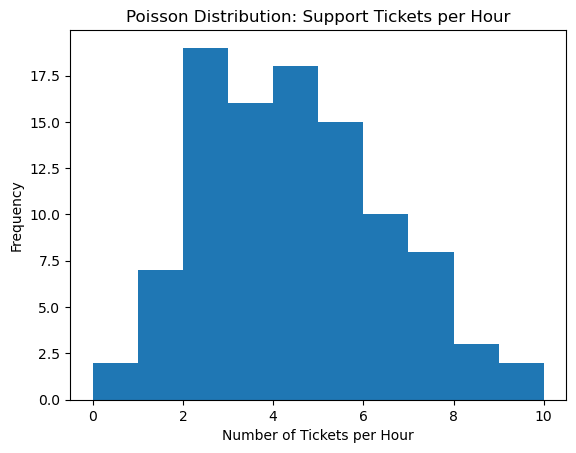

In [15]:
plt.figure()
plt.hist(tickets_per_hour, bins=range(0, tickets_per_hour.max()+2))
plt.xlabel("Number of Tickets per Hour")
plt.ylabel("Frequency")
plt.title("Poisson Distribution: Support Tickets per Hour")
plt.show()

### Interpretation

The simulated distribution of support tickets per hour is **right-skewed**,
with most hours clustering around **3–5 tickets**, and fewer hours showing
very low or very high counts.

This behavior is characteristic of a **Poisson distribution**, where:
- events occur randomly over time,
- the average event rate is stable (λ ≈ 4 tickets/hour),
- the number of events in each interval varies naturally.

The distribution is not symmetric like a normal distribution and cannot take
negative values, which reflects the real-world constraint that event counts
cannot be less than zero.